Transfer-function based velocity invariant for SFDM.

Produces `Velocity_invariant_SFDM/invariant_sf_m=<exp>.npz` files that can be moved into the VFDM repo's `SFDM_data/Velocity_invariant_SFDM/` folder so the VFDM plotting notebook can overlay SFDM curves.

In [1]:
from classy import Class
import numpy as np
from scipy.interpolate import interp1d
from matplotlib import pyplot as plt

plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'


In [2]:
# Planck 2018 TT,TE,EE+lowE
h_planck    = 0.6688
omega_cdm   = 0.1206
omega_b     = 0.02212
tau_reio    = 0.05522
As          = 2.092e-9
ns          = 0.962
theta_s     = 1.04077

z_rec = 1020
a_rec = 1 / (1 + z_rec)


In [3]:
lcdm_settings = {
    'omega_b': omega_b, 'Omega_cdm': omega_cdm / h_planck**2, 'h': h_planck,
    'A_s': As, 'n_s': ns, 'tau_reio': tau_reio, 'YHe': 'BBN',
    'output': 'dTk,vTk', 'gauge': 'synchronous',
    'P_k_max_h/Mpc': 100.0, 'format': 'camb',
    'ic': 'ad', 'P_k_ini type': 'analytic_Pk',
    'Omega_k': 0., 'N_ncdm': 0,
    'k_per_decade_for_pk': 500,
}

precision_settings = {
    'tol_thermo_integration': 1.0e-6,
    'start_small_k_at_tau_c_over_tau_h': 0.0004,
    'start_large_k_at_tau_h_over_tau_k': 0.001,
    'tol_perturbations_integration': 1.e-7,
    'k_per_decade_primordial': 30.0,
}

lcdm = Class()
lcdm.set(lcdm_settings)
lcdm.compute()

frac = 1-1.e-6
common_settings = {
    'output': 'tCl mPk',
    'h': h_planck,
    'Omega_cdm': omega_cdm*(1-frac)/h_planck**2,
    'omega_b': omega_b,
    'N_ncdm': 0,
    'Omega_k': 0.,
    'Omega_fld': 0.,
    'Omega_scf': omega_cdm * frac/ h_planck**2,
    'attractor_ic_scf': 'yes',
    'scf_tuning_index': 3,
    'YHe': 'BBN',
    'tau_reio': tau_reio,
    'ic': 'ad',
    'gauge': 'synchronous',
    'P_k_ini type': 'analytic_Pk',
    'A_s': As,
    'n_s': ns,
    'format': 'camb',
    'k_per_decade_for_pk': 500,
}
common_settings.update(precision_settings) 

## Transfer-function helpers

In [4]:
def compute_transfer_sfdm(mass, k_max_h=100.):
    cosmo = Class()
    cosmo.set(common_settings)
    cosmo.set({
        'scf_parameters': '%s, 1.e-16, 1.e-30, 0.01' % mass,
        'output': 'dTk,vTk',
        'z_pk': z_rec,
        'P_k_max_h/Mpc': k_max_h,
    })
    cosmo.compute()
    tf, prim = cosmo.get_transfer(z=z_rec), cosmo.get_primordial()
    out = {'k_h': tf['k (h/Mpc)'], 'tf': dict(tf),
           'prim_k_perMpc': prim['k [1/Mpc]'], 'prim_pk': prim['P_scalar(k)']}
    cosmo.empty()
    return out


def compute_transfer_lcdm_tf(k_max_h=100.):
    cosmo = Class()
    cosmo.set(lcdm_settings)
    cosmo.set({'P_k_max_h/Mpc': k_max_h, 'z_pk': z_rec, 'output': 'dTk,vTk'})
    cosmo.compute()
    tf, prim = cosmo.get_transfer(z=z_rec), cosmo.get_primordial()
    out = {'k_h': tf['k (h/Mpc)'], 'tf': dict(tf),
           'prim_k_perMpc': prim['k [1/Mpc]'], 'prim_pk': prim['P_scalar(k)']}
    cosmo.empty()
    return out


def velocity_invariant_from_tf(tf_data, theta_subtract='t_vf'):
    k_h = tf_data['k_h']
    k_per_Mpc = k_h * h_planck
    delta_theta = (tf_data['tf']['t_b'] if theta_subtract is None
                   else tf_data['tf']['t_b'] - tf_data['tf'][theta_subtract])
    f_prim = interp1d(tf_data['prim_k_perMpc'], tf_data['prim_pk'],
                      bounds_error=False, fill_value='extrapolate')
    invariant = f_prim(k_per_Mpc) * (delta_theta / k_per_Mpc) ** 2
    return interp1d(k_h, invariant)


def save_invariant_sf(mass, k_out_in_h, k_max_h=100.):
    """Compute and save SFDM TF-invariant. File layout (arr_0=k, arr_1=invariant)
    matches what the VFDM notebook loads via np.load(...)['arr_1']."""
    inv = velocity_invariant_from_tf(compute_transfer_sfdm(mass, k_max_h), 't_scf')
    invariant = inv(k_out_in_h)
    outfile = '../../SFDM_data/Velocity_invariant_SFDM/invariant_sf_m=%s' % (str(mass)[-3:])
    np.savez(outfile, k_out_in_h, invariant)
    print('saved', outfile + '.npz')
    return invariant


def save_invariant_lcdm(mass, k_out_in_h, k_max_h=100.):
    """Compute and save LCDM TF-invariant on the same k grid as the SFDM file
    for this mass, so plot_invariant_sf_vs_cdm can load and compare both."""
    inv = velocity_invariant_from_tf(compute_transfer_lcdm_tf(k_max_h), None)
    invariant = inv(k_out_in_h)
    outfile = '../../SFDM_data/Velocity_invariant_SFDM/invariant_lcdm_m=%s' % (str(mass)[-3:])
    np.savez(outfile, k_out_in_h, invariant)
    print('saved', outfile + '.npz')
    return invariant


def k_jeans(mass):
    background = lcdm.get_background()
    background_a = 1/(1+background['z'])
    background_H_over_m = background['H [1/Mpc]']/(mass * 1.56 * 1.e29)
    a_osc = interp1d(background_H_over_m, background_a)(1.)
    H_osc = interp1d(background_H_over_m, background['H [1/Mpc]'])(1.)
    return a_osc * np.sqrt(mass * 1.56 * 1.e29 * H_osc)


def plot_invariant_sf_vs_cdm(mass, ylim=(1.e-19, 3*1.e-8), kj_text_y=3.e-19):
    """Load the SFDM and CDM invariants saved for `mass` and plot them."""
    tag = str(mass)[-3:]
    data_sf   = np.load('../../SFDM_data/Velocity_invariant_SFDM/invariant_sf_m=%s.npz'   % tag)
    data_lcdm = np.load('../../SFDM_data/Velocity_invariant_SFDM/invariant_lcdm_m=%s.npz' % tag)
    k_out          = data_sf['arr_0']
    invariant_sf   = data_sf['arr_1']
    invariant_lcdm = data_lcdm['arr_1']

    kj = k_jeans(mass)

    plt.figure(figsize=(8, 6))
    plt.grid()
    plt.ylabel(r'$\Delta_{v}^2$', size=22, family='STIXGeneral')
    plt.xlabel(r'k  [h $\mathrm{Mpc}^{-1}$]', size=18, family='STIXGeneral')
    plt.vlines(kj, 1.e-20, 1.e5, colors='dimgrey', linestyles='dashdot', lw=3)
    plt.text(0.6*kj, kj_text_y, r'$k_{J}$', fontdict={'color':'dimgrey', 'fontweight':'bold'}, size=22)
    plt.plot(k_out, invariant_sf,   color='tab:green', linestyle='solid', label='SFDM', lw=3)
    plt.plot(k_out, invariant_lcdm, color='black',     linestyle='dashed', label='CDM',  lw=3)
    plt.tick_params(axis='both', labelsize=18)
    plt.title(r'$m = 10^{%s} \rm{eV}$  -  $z = %s$' % (tag, str(z_rec)), fontsize=22)
    plt.xscale('log')
    plt.yscale('log')
    plt.legend(loc='lower left', fontsize=16)
    plt.ylim(ylim)
    plt.xlim(k_out.min(), k_out.max())
    plt.tight_layout()
    #plt.savefig('../../Figures/Invariant_%s_sfdm_vs_cdm.pdf' % tag, format='pdf')
    plt.show()


## Run for each mass

k-grid matches the VFDM notebook (`np.logspace(-2, log10(100), 800)`) so the resulting `.npz` files drop straight into the VFDM plots.

### $m = 10^{-20} \rm{eV}$

In [5]:
mass = 1.e-20
k_max_h = 100.
k_out_in_h = np.logspace(-2, np.log10(k_max_h), 800)
invariant_sf   = save_invariant_sf(mass, k_out_in_h, k_max_h)
invariant_lcdm = save_invariant_lcdm(mass, k_out_in_h, k_max_h)


saved ../../SFDM_data/Velocity_invariant_SFDM/invariant_sf_m=-20.npz
saved ../../SFDM_data/Velocity_invariant_SFDM/invariant_lcdm_m=-20.npz


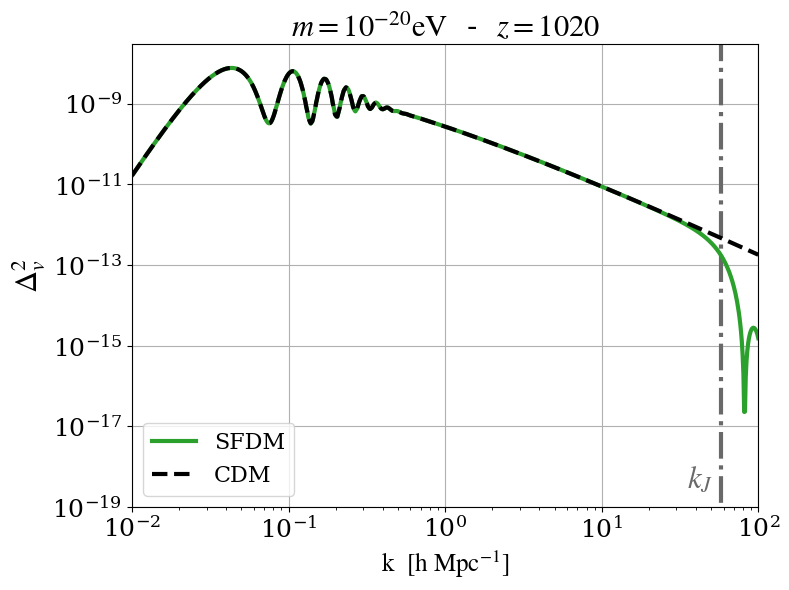

In [6]:
plot_invariant_sf_vs_cdm(mass)


### $m = 10^{-21} \rm{eV}$

In [7]:
mass = 1.e-21
k_max_h = 100.
k_out_in_h = np.logspace(-2, np.log10(k_max_h), 800)
invariant_sf   = save_invariant_sf(mass, k_out_in_h, k_max_h)
invariant_lcdm = save_invariant_lcdm(mass, k_out_in_h, k_max_h)


saved ../../SFDM_data/Velocity_invariant_SFDM/invariant_sf_m=-21.npz
saved ../../SFDM_data/Velocity_invariant_SFDM/invariant_lcdm_m=-21.npz


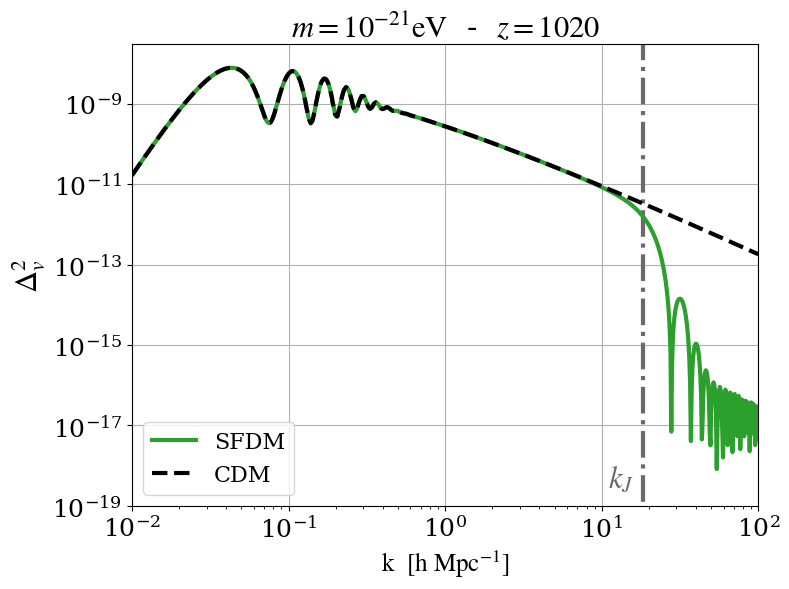

In [8]:
plot_invariant_sf_vs_cdm(mass)


### $m = 10^{-22} \rm{eV}$

In [9]:
mass = 1.e-22
k_max_h = 100.
k_out_in_h = np.logspace(-2, np.log10(k_max_h), 800)
invariant_sf   = save_invariant_sf(mass, k_out_in_h, k_max_h)
invariant_lcdm = save_invariant_lcdm(mass, k_out_in_h, k_max_h)


saved ../../SFDM_data/Velocity_invariant_SFDM/invariant_sf_m=-22.npz
saved ../../SFDM_data/Velocity_invariant_SFDM/invariant_lcdm_m=-22.npz


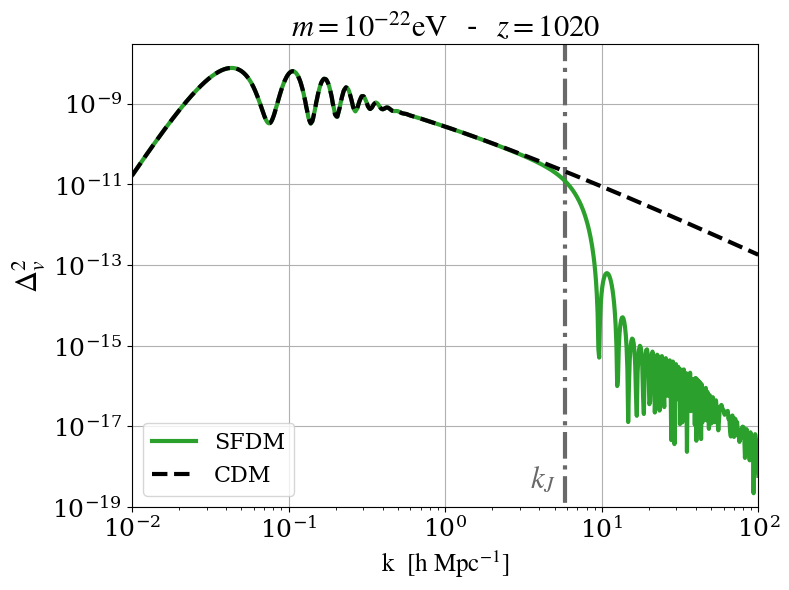

In [10]:
plot_invariant_sf_vs_cdm(mass)


### $m = 10^{-23} \rm{eV}$

In [11]:
mass = 1.e-23
k_max_h = 100.
k_out_in_h = np.logspace(-2, np.log10(k_max_h), 800)
invariant_sf   = save_invariant_sf(mass, k_out_in_h, k_max_h)
invariant_lcdm = save_invariant_lcdm(mass, k_out_in_h, k_max_h)


saved ../../SFDM_data/Velocity_invariant_SFDM/invariant_sf_m=-23.npz
saved ../../SFDM_data/Velocity_invariant_SFDM/invariant_lcdm_m=-23.npz


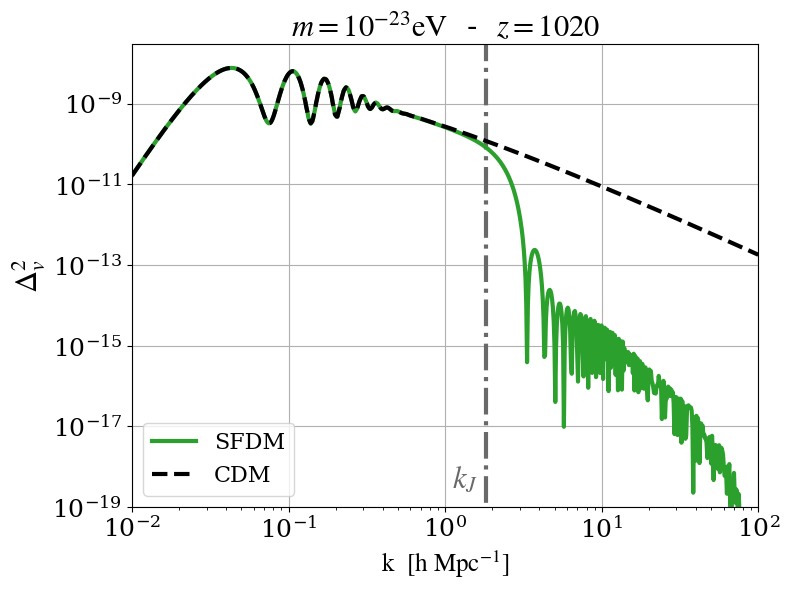

In [12]:
plot_invariant_sf_vs_cdm(mass)


### $m = 10^{-24} \rm{eV}$

In [13]:
mass = 1.e-24
k_max_h = 5.
k_out_in_h = np.logspace(-2, np.log10(k_max_h), 800)
invariant_sf   = save_invariant_sf(mass, k_out_in_h, k_max_h)
invariant_lcdm = save_invariant_lcdm(mass, k_out_in_h, k_max_h)


saved ../../SFDM_data/Velocity_invariant_SFDM/invariant_sf_m=-24.npz
saved ../../SFDM_data/Velocity_invariant_SFDM/invariant_lcdm_m=-24.npz


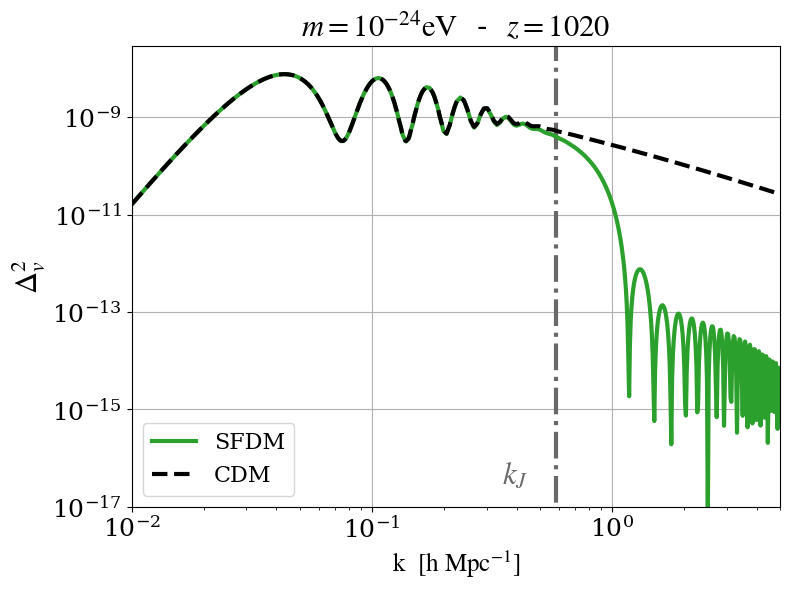

In [14]:
plot_invariant_sf_vs_cdm(mass, ylim=(1.e-17, 3*1.e-8), kj_text_y=3.e-17)


### $m = 10^{-25} \rm{eV}$

In [15]:
mass = 1.e-25
k_max_h = 1.
k_out_in_h = np.logspace(-2, np.log10(k_max_h), 800)
invariant_sf   = save_invariant_sf(mass, k_out_in_h, k_max_h)
invariant_lcdm = save_invariant_lcdm(mass, k_out_in_h, k_max_h)


saved ../../SFDM_data/Velocity_invariant_SFDM/invariant_sf_m=-25.npz
saved ../../SFDM_data/Velocity_invariant_SFDM/invariant_lcdm_m=-25.npz


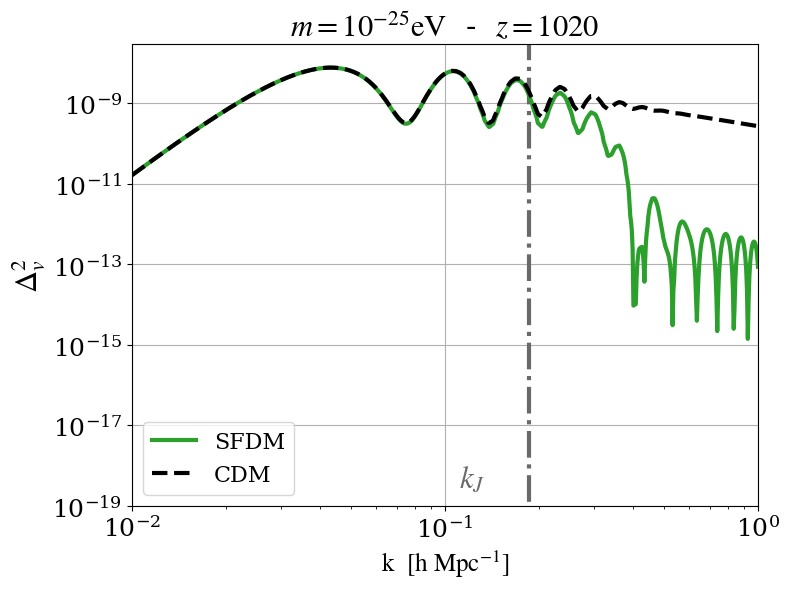

In [16]:
plot_invariant_sf_vs_cdm(mass)
